# Titanic Survival Prediction

Pipeline: Load -> EDA -> Clean -> Visualize -> Feature Eng -> Model -> Evaluate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 1: Load Dataset

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nOverall survival rate: {df["Survived"].mean()*100:.2f}%')

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Overall survival rate: 38.38%


## Step 3: Data Cleaning & Preprocessing

In [6]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
print('Cleaning done! Shape:', df.shape)
print('Missing values after cleaning:', df.isnull().sum().sum())
df.head()

Cleaning done! Shape: (891, 8)
Missing values after cleaning: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## Step 4: Data Visualization

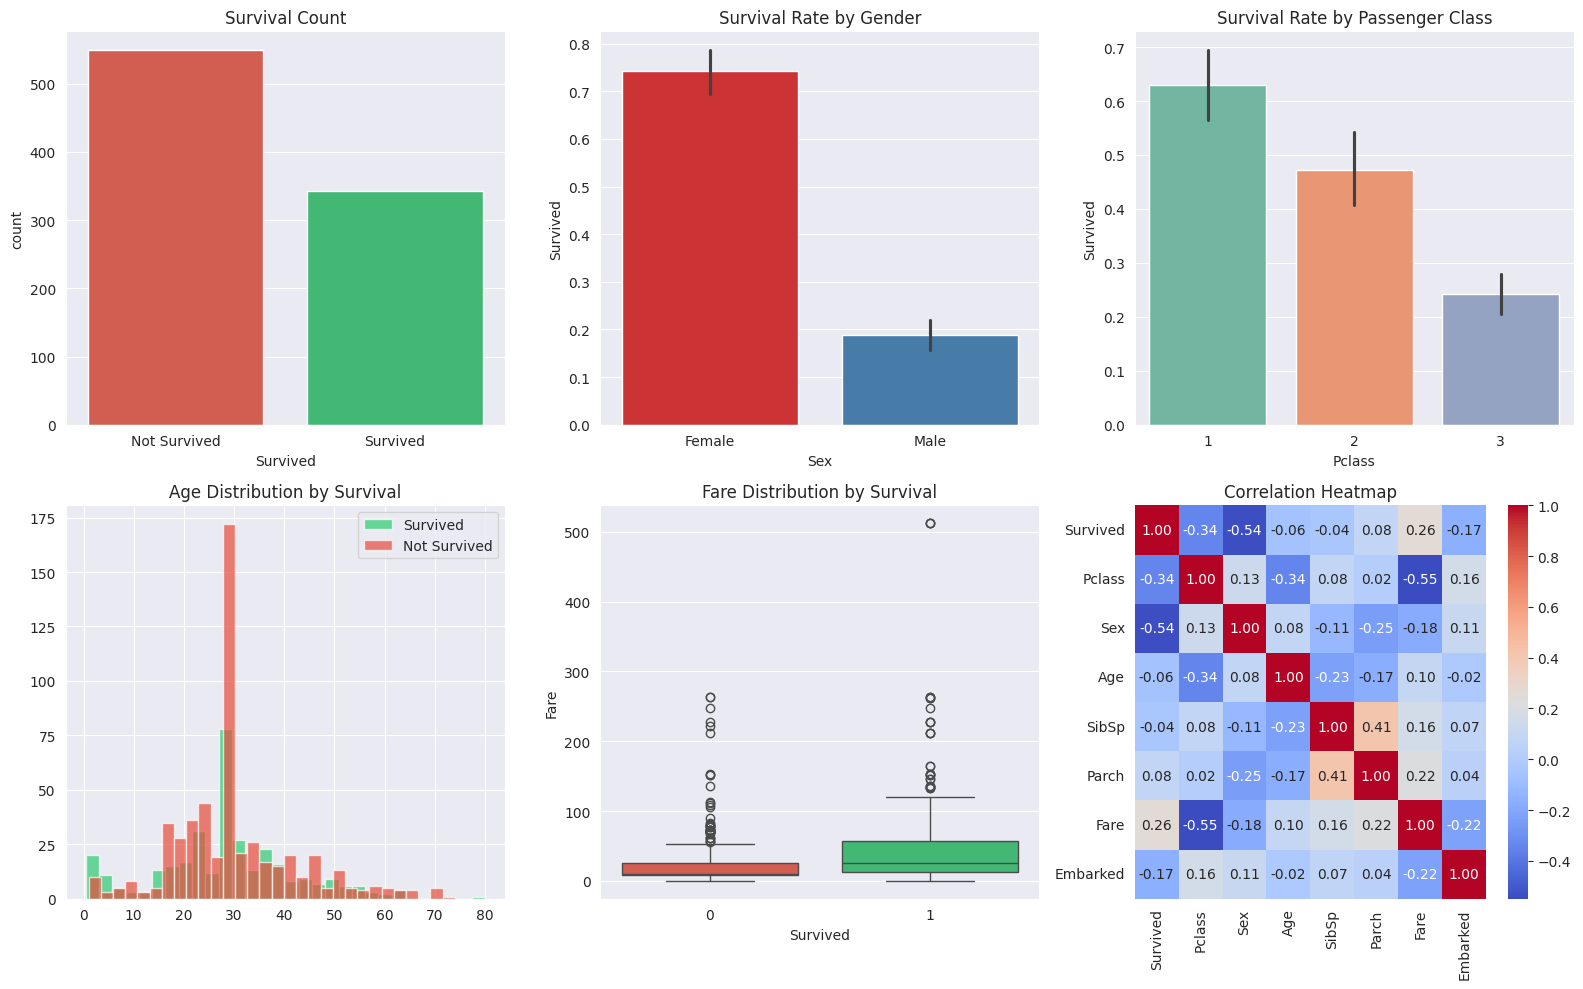

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.countplot(x='Survived', data=df, palette=['#e74c3c','#2ecc71'], ax=axes[0,0])
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Not Survived','Survived'])

sns.barplot(x='Sex', y='Survived', data=df, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Gender')
axes[0,1].set_xticklabels(['Female','Male'])

sns.barplot(x='Pclass', y='Survived', data=df, palette='Set2', ax=axes[0,2])
axes[0,2].set_title('Survival Rate by Passenger Class')

axes[1,0].hist(df[df['Survived']==1]['Age'], bins=30, alpha=0.7, color='#2ecc71', label='Survived')
axes[1,0].hist(df[df['Survived']==0]['Age'], bins=30, alpha=0.7, color='#e74c3c', label='Not Survived')
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].legend()

sns.boxplot(x='Survived', y='Fare', data=df, palette=['#e74c3c','#2ecc71'], ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Survival')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Step 5: Feature Engineering

In [8]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print('New features added: FamilySize, IsAlone')
df[['SibSp','Parch','FamilySize','IsAlone']].head(8)

New features added: FamilySize, IsAlone


,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0


## Step 6: Model Building

In [9]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print('Model trained successfully!')

Training samples: 712
Testing samples : 179
Model trained successfully!


## Step 7: Evaluation

In [10]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

Accuracy: 79.33%

              precision    recall  f1-score   support

Not Survived       0.81      0.86      0.84       110
    Survived       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



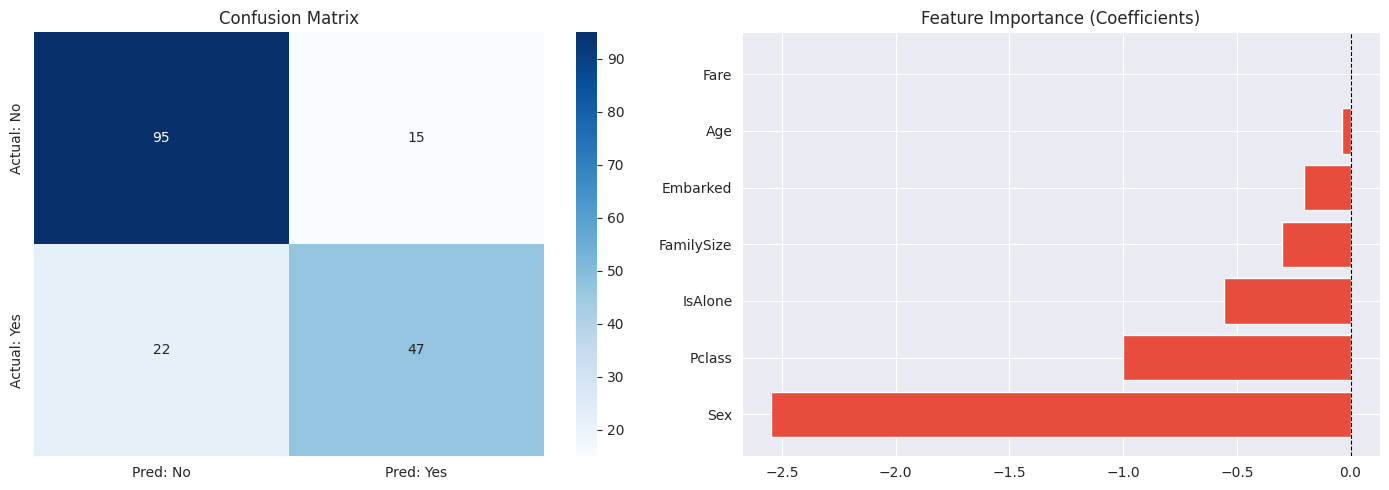

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No','Pred: Yes'],
            yticklabels=['Actual: No','Actual: Yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]}).sort_values('Coefficient')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Feature Importance (Coefficients)')

plt.tight_layout()
plt.show()

## Step 8: Predict a Custom Passenger

In [12]:
# Change these values to test different passengers
# Sex: 0=female, 1=male | Pclass: 1/2/3 | Embarked: 0=C, 1=Q, 2=S
custom = pd.DataFrame({
    'Pclass': [3], 'Sex': [1], 'Age': [25], 'Fare': [7.5],
    'FamilySize': [1], 'IsAlone': [1], 'Embarked': [2]
})

pred = model.predict(custom)[0]
prob = model.predict_proba(custom)[0]

print('--- Passenger: 3rd class, Male, Age 25, Alone ---')
print(f'Prediction    : {"SURVIVED" if pred==1 else "DID NOT SURVIVE"}')
print(f'Survival Prob : {prob[1]*100:.1f}%')

--- Passenger: 3rd class, Male, Age 25, Alone ---
Prediction    : DID NOT SURVIVE
Survival Prob : 10.2%


## Summary

| Step | Action |
|------|--------|
| 1 | Loaded Titanic dataset (891 rows, 12 columns) |
| 2 | EDA - found missing values in Age, Cabin, Embarked |
| 3 | Cleaned data - filled nulls, dropped irrelevant columns, encoded categories |
| 4 | 6 visualizations - survival by gender, class, age, fare, heatmap |
| 5 | Feature Engineering - FamilySize and IsAlone |
| 6 | Logistic Regression with 80/20 train-test split |
| 7 | ~80% accuracy, confusion matrix, feature importance |

**Key Finding:** Sex and Pclass are the strongest predictors of survival.
